In [1]:
import matplotlib.figure as figure
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
from dcekit.validation import double_cross_validation
from sklearn.cross_decomposition import PLSRegression
from dcekit.validation import DCEGridSearchCV
from dcekit.variable_selection import cvpfi

In [2]:
dataset = pd.read_csv('HEA25_A.csv', index_col=0)

In [3]:
dataset.shape

(25, 6)

In [4]:
x = dataset.iloc[:, 1:]

In [5]:
x

,C,F_R,F_M,T,P
1,0.5,50,5.00,225.0,8.5
2,0.5,50,5.00,265.3,8.1
3,0.5,70,7.00,259.6,8.0
5,1.0,70,7.00,261.6,8.1
6,5.0,70,7.00,260.4,8.0
10,5.0,70,9.99,258.8,8.0
11,5.0,70,7.00,269.5,9.5
13,5.0,100,7.00,257.6,8.0
14,5.0,100,7.00,256.3,9.5
19,2.0,85,4.00,194.9,9.5


In [6]:
y = dataset.iloc[:, 0]

In [7]:
max_pls_component_number = 5

inner_fold_number = 5 # "fold_number"-fold cross-validation (CV) for inter CV 
outer_fold_number = x.shape[0]-1 # LOO
model=PLSRegression()

In [8]:
pls_components = np.arange(1, max_pls_component_number)
inner_cv = DCEGridSearchCV(model, {'n_components': pls_components}, cv=inner_fold_number)
estimated_y = double_cross_validation(gs_cv=inner_cv, x=x, y=y, outer_fold_number=outer_fold_number,
                                      do_autoscaling=True, random_state=3)

1 / 24
2 / 24
3 / 24
4 / 24
5 / 24
6 / 24
7 / 24
8 / 24
9 / 24
10 / 24
11 / 24
12 / 24
13 / 24
14 / 24
15 / 24
16 / 24
17 / 24
18 / 24
19 / 24
20 / 24
21 / 24
22 / 24
23 / 24
24 / 24


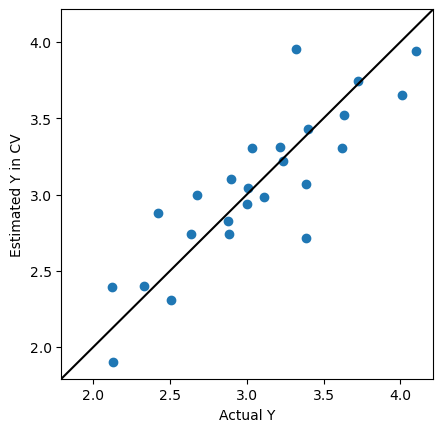

In [9]:
plt.figure(figsize=figure.figaspect(1))
plt.scatter(y, estimated_y)
y_max = np.max(np.array([np.array(y), estimated_y]))
y_min = np.min(np.array([np.array(y), estimated_y]))
plt.plot([y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)],
         [y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)], 'k-')
plt.ylim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))
plt.xlim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))
plt.xlabel('Actual Y')
plt.ylabel('Estimated Y in CV')
plt.show()

In [10]:
print('r2dcv: {0}'.format(float(1 - sum((y - estimated_y) ** 2) / sum((y - y.mean()) ** 2))))

r2dcv: 0.7297270561590146


In [11]:
estimated_y = pd.DataFrame(estimated_y)

In [12]:
estimated_y.to_csv('estimated_y_HER.csv')

In [13]:
autoscaled_x = (x - x.mean(axis=0)) / x.std(axis=0, ddof=1)

In [14]:
# settings
fold_number = 5
n_repeats = 5  # the number of repetition J
alpha_r = 0.999  # alpha (the significance level) in the r (correlation) consideration, 1 means the correlations between features are not considered 

In [15]:
# CVPFI calculation
importances_mean, importances_std, importances = cvpfi(
    model,
    autoscaled_x,
    y,
    fold_number=fold_number,
    scoring='r2',
    n_repeats=n_repeats,
    alpha_r=alpha_r,
    random_state=9,
)

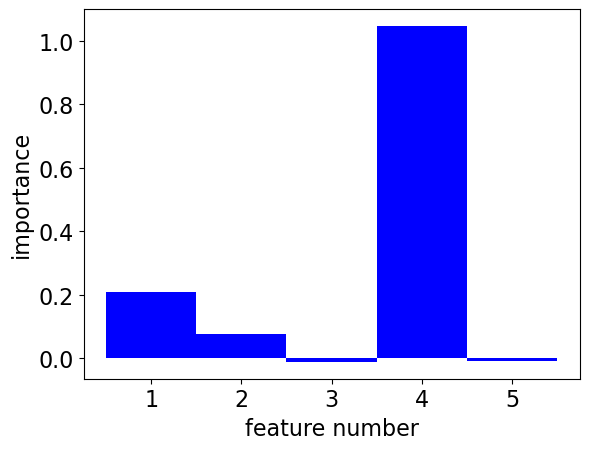

In [16]:
plt.rcParams['font.size'] = 16
plt.bar(range(1, x.shape[1] + 1), importances_mean[range(0, x.shape[1])], color='b', width=1)
plt.xlabel('x')
plt.xlabel('feature number')
plt.ylabel('importance')
plt.show()

In [17]:
importances

array([[ 1.89225284e-01,  1.91087879e-01,  2.68831708e-01,
         2.88726577e-01,  1.02437869e-01],
       [ 1.69523262e-01, -4.64408612e-03,  4.79101200e-02,
         8.20453657e-02,  8.85383121e-02],
       [-1.27498127e-03, -6.38553894e-03, -1.89978842e-02,
        -3.19780921e-02, -6.56559697e-04],
       [ 1.23300948e+00,  1.17306946e+00,  8.43390116e-01,
         1.18288771e+00,  8.04119746e-01],
       [-1.80071219e-02, -4.32361914e-02, -1.12704368e-02,
         9.19319669e-03,  1.42309650e-02]])

In [18]:
importance_mean = importances.mean(axis=1)

In [19]:
importance_mean

array([ 0.20806186,  0.07667459, -0.01185861,  1.0472953 , -0.00981792])

In [20]:
importance = pd.DataFrame(importance_mean) # 標準回帰係数を Pandas の DataFrame 型に変換
importance.index = x.columns # 変数に対応する名前を、元のデータの変数名に
importance.columns = ['importance']
importance.to_csv('importance.csv')

In [21]:
importance_std = importances.std(axis=1)

In [22]:
importance_std

array([0.06633119, 0.05697472, 0.01202677, 0.1840684 , 0.02061905])

In [23]:
importance_std = pd.DataFrame(importances_std)
importance_std.index = x.columns
importance_std.columns = ['importance_std']
importance_std.to_csv('importance_std.csv')

In [24]:
#回帰係数の平均値
from sklearn.model_selection import LeaveOneOut

In [25]:
loo = LeaveOneOut()
coefs = []

In [26]:
for train_index, test_index in loo.split(x):
    x_train = x.iloc[train_index, :]
    x_test = x.iloc[test_index, :]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]
    
    autoscaled_x_train = (x_train - x_train.mean()) / x_train.std() # トレーニングデータの説明変数の標準化。平均を引いてから、標準偏差で割ります
    autoscaled_x_test = (x_test - x_train.mean()) / x_train.std() # テストデータの説明変数の標準化には、トレーニングデータの平均と標準偏差を用いることに注意してください
    autoscaled_y_train = (y_train - y_train.mean()) / y_train.std() # トレーニングデータの目的変数の標準化

    from sklearn import model_selection #クロスバリデーションにより推定値を計算するために使用
    from sklearn.cross_decomposition import PLSRegression # PLS モデル構築やモデルを用いた y の値の推定に使用
    from sklearn import metrics # r2 等の指標の計算に使用

    max_number_of_components = 5 # 最大の主成分数
    fold_number = x.shape[0]-1 # クロスバリデーションのfold数

    components = [] # 空の list を作成して、主成分数をこの変数に追加していきます
    r2_in_cv_all = [] # 空の list を作成して、主成分数ごとのクロスバリデーション後の r2 をこの list に追加していきます

    for component in range(1, max_number_of_components+1):
        model = PLSRegression(n_components=component) # PLS モデルの宣言
        estimated_y_in_cv = pd.DataFrame(model_selection.cross_val_predict(model, autoscaled_x_train, autoscaled_y_train, cv=fold_number)) # クロスバリデーション推定値の計算し、DataFrame型に変換
        estimated_y_in_cv = estimated_y_in_cv * y_train.std() + y_train.mean() # スケールをもとに戻す
        r2_in_cv = metrics.r2_score(y_train, estimated_y_in_cv) # r2 を計算
        r2_in_cv_all.append(r2_in_cv)  # r2 を追加
        components.append(component) # 主成分数を追加

    optimal_component_number = components[r2_in_cv_all.index(max(r2_in_cv_all))] # 最良の主成分数を optimal_component_number に代入
    
    model = PLSRegression(n_components=optimal_component_number)
    model.fit(autoscaled_x_train, autoscaled_y_train)

    coefs.append(model.coef_.ravel())

In [27]:
coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_std = coefs.std(axis=0)

In [28]:
coefs

array([[-0.32706148, -0.18023299, -0.00793504,  0.76747007, -0.19184024],
       [-0.35999843, -0.21772758, -0.00194721,  0.77171983, -0.18351217],
       [-0.35751567, -0.22460398, -0.01758407,  0.76279811, -0.17374244],
       [-0.35457446, -0.27788692,  0.02811542,  0.73390537, -0.11848193],
       [-0.31621422, -0.21909376, -0.01829179,  0.7502514 , -0.18018667],
       [-0.34472308, -0.23544897, -0.0157169 ,  0.7340869 , -0.15201246],
       [-0.41727421, -0.20767156,  0.02552839,  0.65475237, -0.18357132],
       [-0.38583197, -0.32897665, -0.00372664,  0.69037685, -0.07777633],
       [-0.32303012, -0.15968526, -0.01179929,  0.80009032, -0.11412107],
       [-0.39464259, -0.22837471,  0.01982608,  0.74420821, -0.0936751 ],
       [-0.43217893, -0.24777203,  0.08099982,  0.72285103, -0.15721308],
       [-0.35675708, -0.21788486, -0.01388793,  0.74870437, -0.16787429],
       [-0.3373686 , -0.21741119, -0.02296685,  0.75154695, -0.16809757],
       [-0.36924825, -0.23630364,  0.0

In [29]:
coef_mean

array([-3.64023515e-01, -2.26565954e-01,  6.43690518e-04,  7.41260829e-01,
       -1.51445952e-01])

In [30]:
coef_std

array([0.02857132, 0.03002756, 0.02845226, 0.02777825, 0.03051575])

In [31]:
coef_mean = pd.DataFrame(coef_mean) # 標準回帰係数を Pandas の DataFrame 型に変換
coef_std = pd.DataFrame(coef_std)

In [32]:
coef_mean.index = x_train.columns # 変数に対応する名前を、元のデータの変数名に
coef_std.index = x_train.columns

In [33]:
coef_mean.columns = ['coef_mean'] # 列名を変更
coef_std.columns = ['coef_std']

In [34]:
coef_mean.to_csv('coef_mean.csv') 
coef_std.to_csv('coef_std.csv')